In [1]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
df.shape

(1000, 8)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

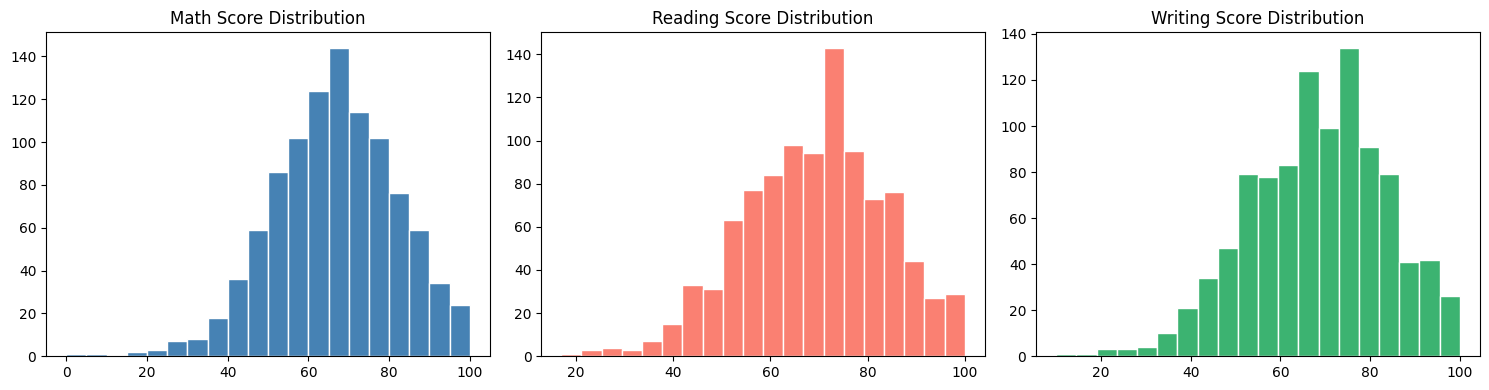

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['math score'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Math Score Distribution')

axes[1].hist(df['reading score'], bins=20, color='salmon', edgecolor='white')
axes[1].set_title('Reading Score Distribution')

axes[2].hist(df['writing score'], bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Writing Score Distribution')

plt.tight_layout()
plt.savefig("score_distributions.png")
plt.show()

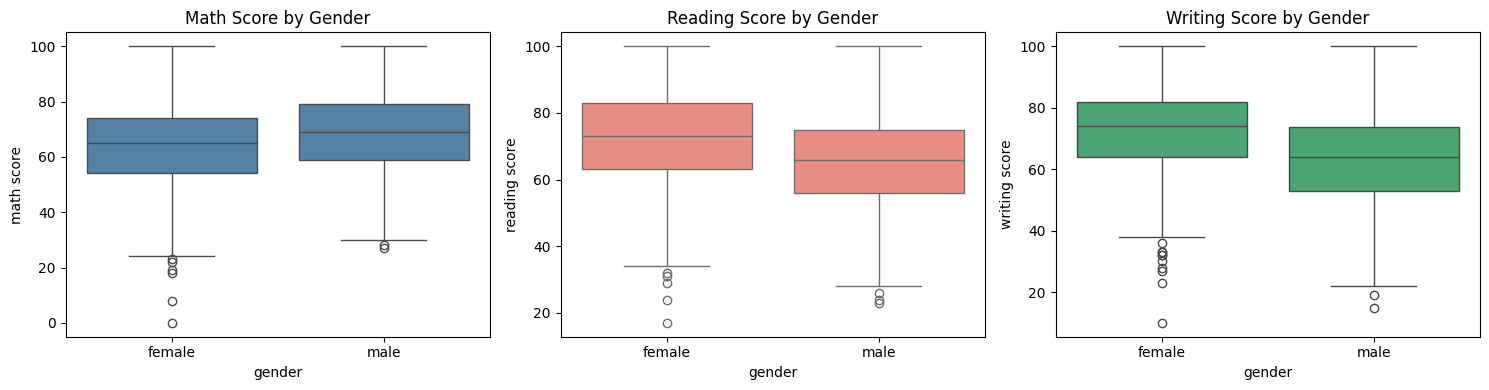

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                          ['math score', 'reading score', 'writing score'],
                          ['steelblue', 'salmon', 'mediumseagreen']):
    sns.boxplot(x='gender', y=col, data=df, ax=ax, color=color)
    ax.set_title(f'{col.title()} by Gender')

plt.tight_layout()
plt.savefig("scores_by_gender.png")
plt.show()

/var/folders/73/lxd1ybl915b3cvvbj765q2c40000gn/T/ipykernel_5192/179183859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parental level of education', y='avg_score',


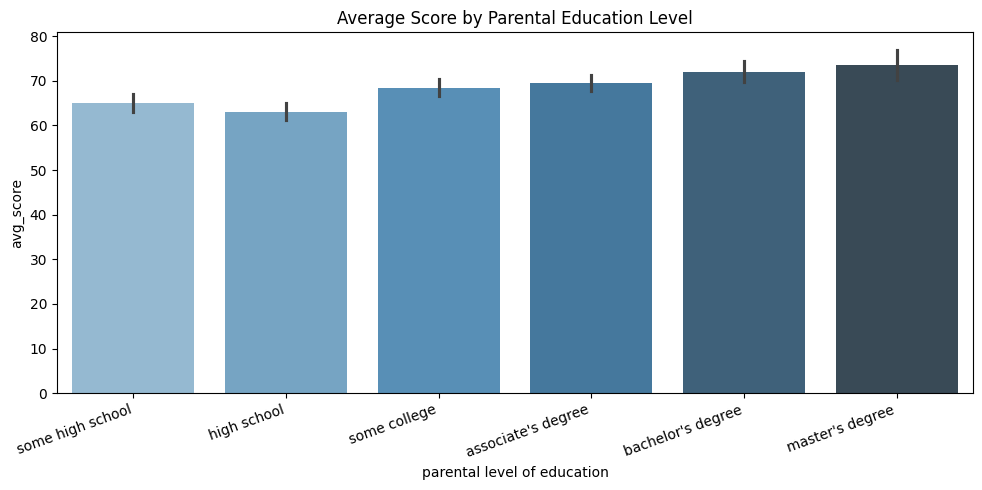

In [8]:
df['avg_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

order = ['some high school', 'high school', 'some college',
         "associate's degree", "bachelor's degree", "master's degree"]

plt.figure(figsize=(10, 5))
sns.barplot(x='parental level of education', y='avg_score',
            data=df, order=order, palette='Blues_d')
plt.xticks(rotation=20, ha='right')
plt.title('Average Score by Parental Education Level')
plt.tight_layout()
plt.savefig("scores_by_parent_edu.png")
plt.show()

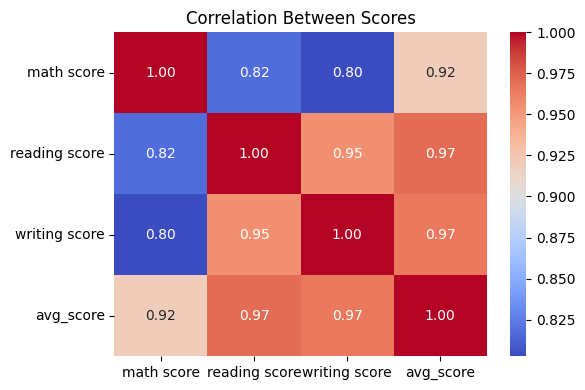

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['math score', 'reading score', 'writing score', 'avg_score']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Scores')
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['gender_enc']    = le.fit_transform(df['gender'])
df['lunch_enc']     = le.fit_transform(df['lunch'])
df['prep_enc']      = le.fit_transform(df['test preparation course'])
df['parent_enc']    = le.fit_transform(df['parental level of education'])
df['race_enc']      = le.fit_transform(df['race/ethnicity'])

print("Encoding done!")
print(df[['gender', 'gender_enc', 'lunch', 'lunch_enc']].head())

Encoding done!
   gender  gender_enc         lunch  lunch_enc
0  female           0      standard          1
1  female           0      standard          1
2  female           0      standard          1
3    male           1  free/reduced          0
4    male           1      standard          1


In [11]:
# Already created avg_score earlier, just adding the flag
df['high_performer'] = (df['avg_score'] >= 70).astype(int)

print(f"High performers: {df['high_performer'].sum()}")
print(f"Others: {(df['high_performer'] == 0).sum()}")
df[['avg_score', 'high_performer']].head(10)

High performers: 459
Others: 541


,avg_score,high_performer
0,72.666667,1
1,82.333333,1
2,92.666667,1
3,49.333333,0
4,76.333333,1
5,77.333333,1
6,91.666667,1
7,40.666667,0
8,65.000000,0
9,49.333333,0


In [12]:
from sklearn.model_selection import train_test_split

features = ['gender_enc', 'lunch_enc', 'prep_enc', 'parent_enc', 'race_enc']
X = df[features]
y_reg = df['avg_score']       # for regression
y_clf = df['high_performer']  # for classification

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 800
Testing samples:  200


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"R² Score : {r2_score(y_test, pred_lr):.3f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, pred_lr)):.2f}")

=== Linear Regression ===
R² Score : 0.126
RMSE     : 13.69


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("=== Random Forest Regressor ===")
print(f"R² Score : {r2_score(y_test, pred_rf):.3f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, pred_rf)):.2f}")

=== Random Forest Regressor ===
R² Score : -0.029
RMSE     : 14.85


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train2, y_train2)
pred_clf = clf.predict(X_test2)

print("=== Random Forest Classifier ===")
print(f"Accuracy : {accuracy_score(y_test2, pred_clf):.3f}")

=== Random Forest Classifier ===
Accuracy : 0.585


In [16]:
# Use math score + demographics to predict reading score
features2 = ['math score', 'gender_enc', 'lunch_enc', 'prep_enc', 'parent_enc']
X2 = df[features2]
y2 = df['reading score']

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

lr2 = LinearRegression()
lr2.fit(X_train3, y_train3)
pred_lr2 = lr2.predict(X_test3)

rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X_train3, y_train3)
pred_rf2 = rf2.predict(X_test3)

print("=== Predicting Reading Score ===")
print(f"Linear Regression  R²: {r2_score(y_test3, pred_lr2):.3f}")
print(f"Random Forest      R²: {r2_score(y_test3, pred_rf2):.3f}")
print(f"Random Forest    RMSE: {np.sqrt(mean_squared_error(y_test3, pred_rf2)):.2f}")

=== Predicting Reading Score ===
Linear Regression  R²: 0.845
Random Forest      R²: 0.792
Random Forest    RMSE: 6.86


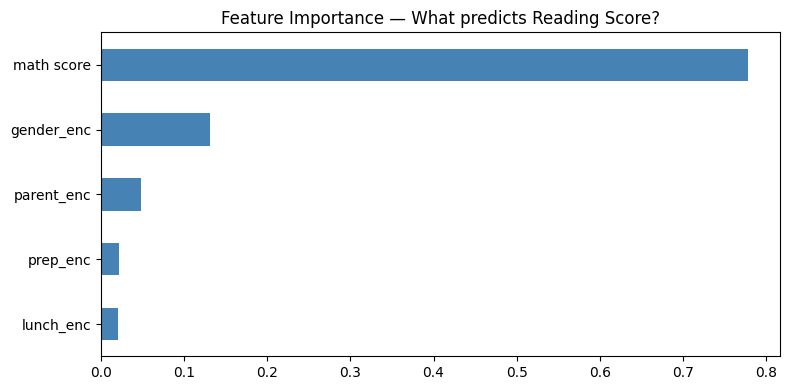

In [17]:
importances = pd.Series(rf2.feature_importances_, index=features2)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('Feature Importance — What predicts Reading Score?')
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [18]:
import joblib

joblib.dump(lr2, "model.pkl")
joblib.dump(rf2, "rf_model.pkl")
print("Models saved!")

Models saved!


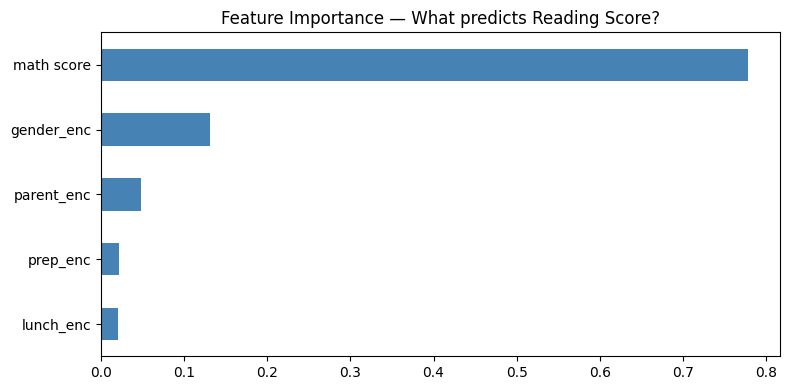

Chart saved!


In [19]:
importances = pd.Series(rf2.feature_importances_, index=features2)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('Feature Importance — What predicts Reading Score?')
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
print("Chart saved!")